In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE


In [3]:
# STEP 2 - LOAD THE DATASET
# ============================================================

df = pd.read_csv("C:/Users/VIHANGI/Desktop/4th YEAR 1st SEM/brain_stroke.csv")

In [4]:
# STEP 3 - DATA UNDERSTANDING
# ============================================================

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Values")
print(df.duplicated().sum())

First 5 Rows
   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1    Male  80.0             0              1          Yes        Private   
2  Female  49.0             0              0          Yes        Private   
3  Female  79.0             1              0          Yes  Self-employed   
4    Male  81.0             0              0          Yes        Private   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
0          Urban             228.69  36.6  formerly smoked       1  
1          Rural             105.92  32.5     never smoked       1  
2          Urban             171.23  34.4           smokes       1  
3          Rural             174.12  24.0     never smoked       1  
4          Urban             186.21  29.0  formerly smoked       1  

Dataset Shape
(4981, 11)

Column Names
Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
   

In [5]:
# STEP 4 - DATA PREPROCESSING
# ============================================================

# Remove duplicate records

df = df.drop_duplicates()

In [6]:
# STEP 5 - ONE-HOT ENCODING
# ============================================================

# Convert categorical variables into dummy variables

df = pd.get_dummies(
    df,
    columns=[
        'gender',
        'ever_married',
        'work_type',
        'Residence_type',
        'smoking_status'
    ],
    drop_first=True
)

# Display new variables after encoding

print("\nEncoded Variables")
print(df.columns)


Encoded Variables
Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke', 'gender_Male', 'ever_married_Yes', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'],
      dtype='object')


In [7]:
# STEP 6 - DEFINE FEATURES AND TARGET VARIABLE
# ============================================================

X = df.drop('stroke', axis=1)

y = df['stroke']


In [8]:
# STEP 7 - TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
# STEP 8 - FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [10]:
# STEP 9 - HANDLE CLASS IMBALANCE USING SMOTE
# ============================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [16]:
# STEP 10 - CREATE MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_test, y_test):

    # Generate predictions
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    # ========================================================
    # EVALUATION METRICS
    # ========================================================

    print("Accuracy:",
          accuracy_score(y_test, y_pred))

    print("Precision:",
          precision_score(y_test, y_pred))

    print("Recall:",
          recall_score(y_test, y_pred))

    print("F1 Score:",
          f1_score(y_test, y_pred))

    print("ROC-AUC:",
          roc_auc_score(y_test, y_prob))
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        "Confusion Matrix",
        fontsize=14,
        fontweight='bold'
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()





LOGISTIC REGRESSION MODEL
Accuracy: 0.7482447342026078
Precision: 0.1423487544483986
Recall: 0.8
F1 Score: 0.24169184290030213
ROC-AUC: 0.8389862724392819

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       947
           1       0.14      0.80      0.24        50

    accuracy                           0.75       997
   macro avg       0.56      0.77      0.55       997
weighted avg       0.94      0.75      0.82       997



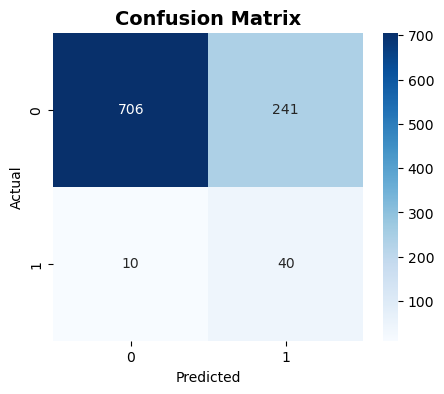

In [17]:
# STEP 11 - LOGISTIC REGRESSION MODEL
# ============================================================

print("\n")
print("================================================")
print("LOGISTIC REGRESSION MODEL")
print("================================================")

# Create model

log_model = LogisticRegression(random_state=42)

# Train model

log_model.fit(X_train_smote, y_train_smote)

# Evaluate model

evaluate_model(log_model, X_test_scaled, y_test)


In [18]:
# DISPLAY LOGISTIC REGRESSION COEFFICIENTS
# ============================================================

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': log_model.coef_[0]
})

print("\nLogistic Regression Coefficients")
print(coef_df)

print("\nIntercept")
print(log_model.intercept_[0])


Logistic Regression Coefficients
                          Variable  Coefficient
0                              age     1.986584
1                     hypertension     0.169599
2                    heart_disease     0.016896
3                avg_glucose_level     0.186212
4                              bmi     0.060450
5                      gender_Male    -0.059418
6                 ever_married_Yes     0.130973
7                work_type_Private     0.344196
8          work_type_Self-employed     0.092018
9               work_type_children     0.769795
10            Residence_type_Urban     0.005481
11  smoking_status_formerly smoked     0.022917
12     smoking_status_never smoked    -0.157404
13           smoking_status_smokes     0.093985

Intercept
-1.2462355071850246




RANDOM FOREST MODEL
Accuracy: 0.8966900702106319
Precision: 0.09230769230769231
Recall: 0.12
F1 Score: 0.10434782608695652
ROC-AUC: 0.8096409714889123

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       947
           1       0.09      0.12      0.10        50

    accuracy                           0.90       997
   macro avg       0.52      0.53      0.52       997
weighted avg       0.91      0.90      0.90       997



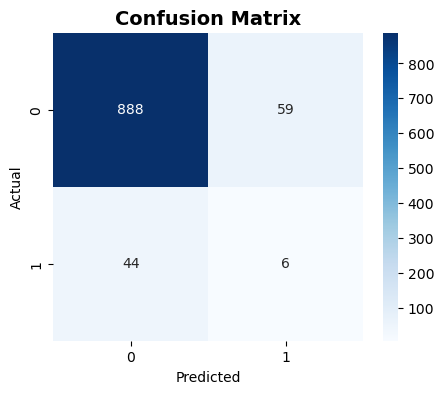

In [19]:
# STEP 12 - RANDOM FOREST MODEL
# ============================================================

print("\n")
print("================================================")
print("RANDOM FOREST MODEL")
print("================================================")

# Create model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model

rf_model.fit(X_train_smote, y_train_smote)

# Evaluate model

evaluate_model(rf_model, X_test_scaled, y_test)

In [20]:
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nRandom Forest Feature Importance")
print(importance_df)



Random Forest Feature Importance
                           Feature  Importance
0                              age    0.345988
3                avg_glucose_level    0.144361
4                              bmi    0.140843
6                 ever_married_Yes    0.081338
10            Residence_type_Urban    0.052328
5                      gender_Male    0.050007
1                     hypertension    0.033802
7                work_type_Private    0.033738
12     smoking_status_never smoked    0.031310
11  smoking_status_formerly smoked    0.019128
8          work_type_Self-employed    0.018899
13           smoking_status_smokes    0.017494
2                    heart_disease    0.015467
9               work_type_children    0.015297


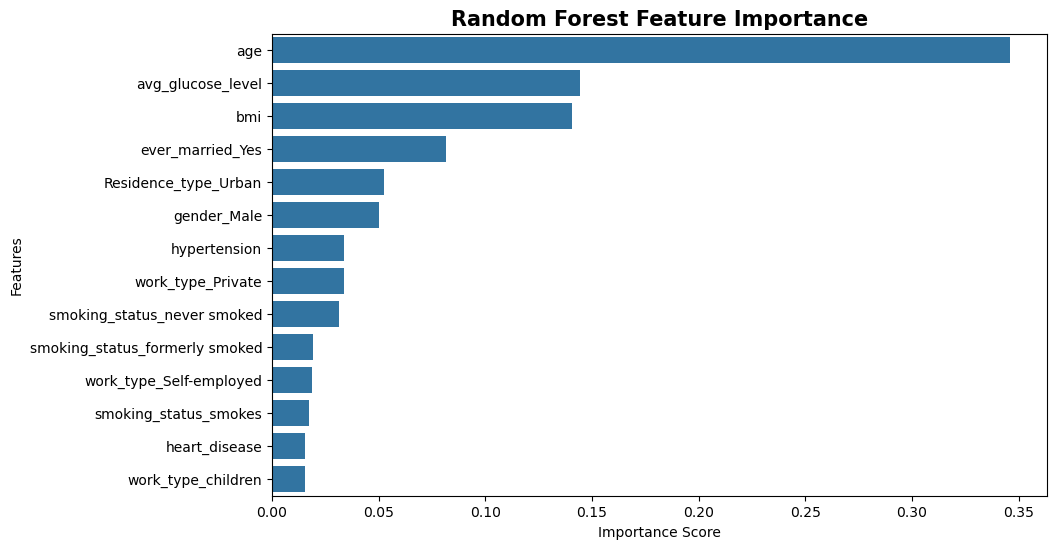

In [21]:
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    color='#1F77B4'
)

plt.title(
    'Random Forest Feature Importance',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()



K-NEAREST NEIGHBORS MODEL
Accuracy: 0.8144433299899699
Precision: 0.10526315789473684
Recall: 0.36
F1 Score: 0.16289592760180996
ROC-AUC: 0.6429355860612461

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.84      0.90       947
           1       0.11      0.36      0.16        50

    accuracy                           0.81       997
   macro avg       0.53      0.60      0.53       997
weighted avg       0.92      0.81      0.86       997



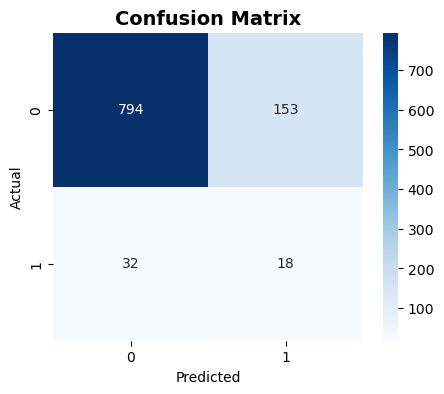

In [22]:
# STEP 13 - K-NEAREST NEIGHBORS MODEL
# ============================================================

print("\n")
print("================================================")
print("K-NEAREST NEIGHBORS MODEL")
print("================================================")

# Create model

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train model

knn_model.fit(X_train_smote, y_train_smote)

# Evaluate model

evaluate_model(knn_model, X_test_scaled, y_test)

<Figure size 800x600 with 0 Axes>

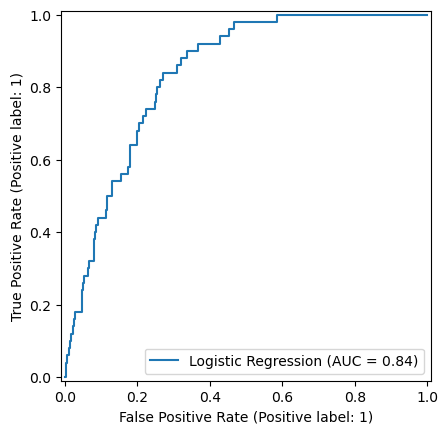

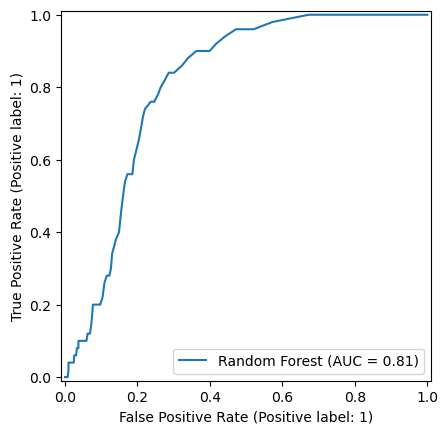

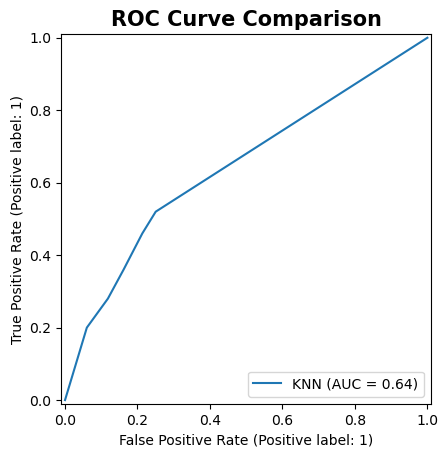

In [23]:
# STEP 14 - ROC CURVE COMPARISON
# ============================================================

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test,
    name='Logistic Regression'
)

RocCurveDisplay.from_estimator(
    rf_model,
    X_test_scaled,
    y_test,
    name='Random Forest'
)

RocCurveDisplay.from_estimator(
    knn_model,
    X_test_scaled,
    y_test,
    name='KNN'
)

plt.title(
    'ROC Curve Comparison',
    fontsize=15,
    fontweight='bold'
)

plt.show()

In [24]:
# STEP 15 - MODEL COMPARISON TABLE
# ============================================================

models = [
    'Logistic Regression',
    'Random Forest',
    'KNN'
]

accuracies = [

    accuracy_score(
        y_test,
        log_model.predict(X_test_scaled)
    ),

    accuracy_score(
        y_test,
        rf_model.predict(X_test_scaled)
    ),

    accuracy_score(
        y_test,
        knn_model.predict(X_test_scaled)
    )
]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print("\nModel Comparison")
print(comparison_df)


Model Comparison
                 Model  Accuracy
0  Logistic Regression  0.748245
1        Random Forest  0.896690
2                  KNN  0.814443
